# Late Delivery Risk Scoring — Supply Chain Optimization

**Capstone · Main notebook**

We solve two linked problems in one pipeline:

1. **Classification** — *Will this order be late?* (target: `Late_delivery_risk` 0/1).  
2. **Regression** — *By how many days?* (target: `Delay_Gap` = real − scheduled days).  

Combined, we produce an **actionable Risk Score**: probability of late × severity of delay, so logistics can prioritize the worst cases first.

| Track | Supervised Learning — **Classification + Regression** |
|-------|--------------------------------------------------------|
| Dataset | E-commerce supply chain (order, shipping, customer, product) |
| Targets | `Late_delivery_risk` (binary), `Delay_Gap` (numeric) |
| Success | Recall ≥ 75%, F1 ≥ 70% on late class; interpretable risk score and feature importance |

**Colab:** Upload CSV via **Files** → set `data_path` in the load cell (e.g. `Path("/content/supply_chain.csv")`).  
**Local:** Put CSV in `data/supply_chain.csv`.

---

## 1. Setup and load data

In [13]:
# Run once if you get ModuleNotFoundError; then restart kernel and run again.
%pip install pandas numpy matplotlib seaborn scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve,
    classification_report, mean_squared_error, r2_score
)

# Reproducibility and display
RNG = 42
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
%matplotlib inline

In [15]:
# Load data. In Colab, set data_path to your uploaded file (e.g. Path("/content/supply_chain.csv")).
candidates = [
    Path('../data/supply_chain.csv'), Path('data/supply_chain.csv'), Path('supply_chain.csv'),
    Path('../data/Data.csv'), Path('data/Data.csv'), Path('Data.csv'),
]
data_path = None
for p in candidates:
    if p.exists():
        data_path = p
        break
if data_path is None:
    for folder in [Path('../data'), Path('data'), Path('.')]:
        if folder.exists():
            csvs = list(folder.glob('*.csv'))
            if csvs:
                data_path = csvs[0]
                break
if data_path is None:
    raise FileNotFoundError("No CSV found. Put dataset in data/ as supply_chain.csv or set data_path in Colab.")
df = pd.read_csv(data_path, low_memory=False, encoding='latin1')
print(f"Loaded: {data_path} -> shape {df.shape}")
df.shape

Loaded: ..\data\supply_chain.csv -> shape (180519, 53)


(180519, 53)

### 1.1 Column check

We need the **classification target** (`Late_delivery_risk`), the **regression target** (`Delay_Gap`, built in cleaning), and key features (shipping days, mode, region, market, segment, category). Delivery Status is excluded from features to avoid leakage.

In [16]:
# Targets: classification (late vs not) and regression (how many days late).
TARGET = 'Late_delivery_risk'       # binary: 0 = on time, 1 = late
TARGET_REG = 'Delay_Gap'             # numeric: real_days - scheduled_days (built in §2)

key_cols = [TARGET, 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Shipping Mode',
            'Order Region', 'Market', 'Customer Segment', 'Category Name']
found = [c for c in key_cols if c in df.columns]
print('Key columns present:', found)
if TARGET in df.columns:
    print('\nClass balance (Late_delivery_risk):')
    print(df[TARGET].value_counts().to_string())
    print(f'\nLate rate: {df[TARGET].mean():.2%}')
df[found].head() if found else df.head()

Key columns present: ['Late_delivery_risk', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Shipping Mode', 'Order Region', 'Market', 'Customer Segment', 'Category Name']

Class balance (Late_delivery_risk):
Late_delivery_risk
1    98977
0    81542

Late rate: 54.83%


,Late_delivery_risk,Days for shipping (real),Days for shipment (scheduled),Shipping Mode,Order Region,Market,Customer Segment,Category Name
0,0,3,4,Standard Class,Southeast Asia,Pacific Asia,Consumer,Sporting Goods
1,1,5,4,Standard Class,South Asia,Pacific Asia,Consumer,Sporting Goods
2,0,4,4,Standard Class,South Asia,Pacific Asia,Consumer,Sporting Goods
3,0,3,4,Standard Class,Oceania,Pacific Asia,Home Office,Sporting Goods
4,0,2,4,Standard Class,Oceania,Pacific Asia,Corporate,Sporting Goods


---

## 2. Data cleaning

- **Drop:** PII (no predictive value, privacy), sparse/irrelevant columns (e.g. Product Description, Order Zipcode), redundant IDs (we keep category *name*, not ID).
- **Rows:** Remove duplicates and any row missing `Late_delivery_risk`.
- **Dates:** Parse order/shipping date strings (mixed formats → `errors='coerce'`).
- **Derive:** `Delay_Gap = Days for shipping (real) − Days for shipment (scheduled)`. Positive = shipped later than promised; this is our **regression target** for “how late.”

**🧒 In simple words:** We’re making the data tidy and safe so the computer can learn from it — like cleaning your room so you can find your toys.

1. **Throw away stuff we don’t need**  
   - **Private stuff** (name, email, address, password): we’re not allowed to use it to predict, and it doesn’t help anyway.  
   - **Useless stuff** (long product descriptions, extra IDs): they don’t help the model.  
   So we **drop** those columns (fewer columns, same rows).

2. **No copies**  
   If the same order appears twice, we keep it only once — **drop duplicates**.

3. **No missing answer**  
   We need to know for each row: “Was it late? Yes or no.” If that answer is missing, we **drop that row** (we can’t learn from it).

4. **Fix the calendar**  
   Dates are written in different ways in the file. We turn them into real dates the computer understands. If something can’t be a date, we mark it empty (**errors='coerce'**).

5. **Make one new number: “How late?”**  
   We already have “days we said it would take” and “days it really took.” We subtract:  
   **Delay_Gap = real days − promised days**.  
   - If it’s **positive** → we were late by that many days.  
   - If it’s **zero or negative** → we were on time or early.  
   That number is what we’ll try to *predict* later (regression).

In [17]:
# Column groups to drop (see DataDiscovery / PROPOSAL data dictionary)
COLS_PII = [
    'Customer Fname', 'Customer Lname', 'Customer Email', 'Customer Password',
    'Customer Street', 'Customer City', 'Customer Country', 'Customer State', 'Customer Zipcode'
]
COLS_DROP = ['Order Zipcode', 'Product Description', 'Product Image', 'Order Profit Per Order']
COLS_REDUNDANT_ID = ['Order Customer Id', 'Order Item Cardprod Id', 'Product Category Id']

to_drop = [c for c in COLS_PII + COLS_DROP + COLS_REDUNDANT_ID if c in df.columns]
work = df.drop(columns=to_drop, errors='ignore')

work = work.drop_duplicates()
work = work.dropna(subset=[TARGET])

work['order date (DateOrders)'] = pd.to_datetime(work['order date (DateOrders)'], errors='coerce')
work['shipping date (DateOrders)'] = pd.to_datetime(work['shipping date (DateOrders)'], errors='coerce')

# Regression target: positive = shipped later than promised
work[TARGET_REG] = work['Days for shipping (real)'] - work['Days for shipment (scheduled)']

print(f"Cleaned: {work.shape[0]:,} rows × {work.shape[1]} cols (from {df.shape[0]:,} × {df.shape[1]})")
work.info()

Cleaned: 180,519 rows × 38 cols (from 180,519 × 53)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer Id                    180519 non-null  int64         
 10  Customer Segment

---

## 3. Exploratory data analysis

Sanity-check class balance, the distribution of **Delay_Gap** (our regression target), and how late rate and average delay vary by **Shipping Mode** and **Order Region**. These patterns inform feature choice and the risk-score interpretation.

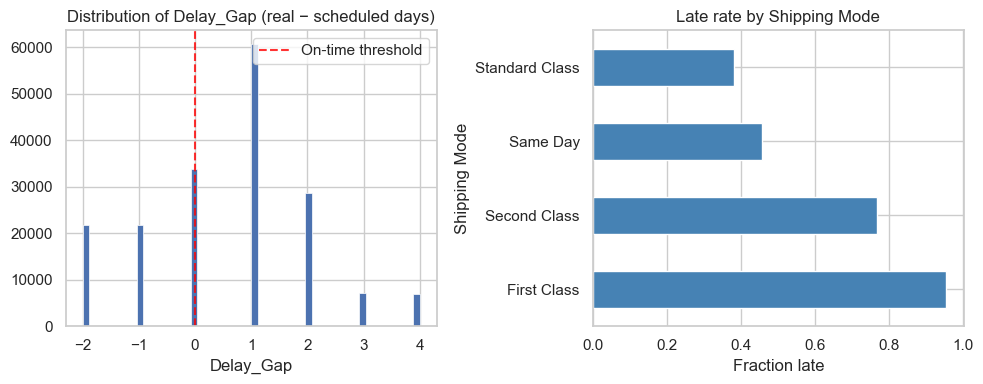

Late rate and mean Delay_Gap by Shipping Mode:
                late_rate  mean_delay
Shipping Mode                        
First Class         0.953       1.000
Second Class        0.766       1.991
Same Day            0.457       0.478
Standard Class      0.381      -0.004

Delay_Gap: mean=0.57, std=1.49, min=-2, max=4


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: Delay_Gap distribution (regression target)
work[TARGET_REG].hist(bins=50, ax=axes[0], edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Delay_Gap (real − scheduled days)')
axes[0].set_xlabel('Delay_Gap')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.8, label='On-time threshold')
axes[0].legend()

# Right: Late rate by Shipping Mode
late_by_mode = work.groupby('Shipping Mode').agg(
    late_rate=(TARGET, 'mean'),
    mean_delay=(TARGET_REG, 'mean')
).sort_values('late_rate', ascending=False)
late_by_mode['late_rate'].plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Late rate by Shipping Mode')
axes[1].set_xlabel('Fraction late')
plt.tight_layout()
plt.show()

print('Late rate and mean Delay_Gap by Shipping Mode:')
print(late_by_mode.round(3).to_string())
print(f'\nDelay_Gap: mean={work[TARGET_REG].mean():.2f}, std={work[TARGET_REG].std():.2f}, min={work[TARGET_REG].min()}, max={work[TARGET_REG].max()}')

---

## 4. Feature engineering

Build a single feature matrix **X** for both the classifier and the regressor. We **one-hot encode** categoricals (Shipping Mode, Order Region, Market, Customer Segment, Category Name, etc.) and keep numeric columns (e.g. days real/scheduled, discount rate). **Exclude** `Delivery Status` and any target columns to avoid leakage.

In [21]:
# Categoricals to one-hot; numerics as-is. Exclude targets and leakage (e.g. Delivery Status).
EXCLUDE_FROM_FEATURES = [TARGET, TARGET_REG, 'Delivery Status', 'order date (DateOrders)', 'shipping date (DateOrders)']
MAX_CATEGORIES = 25  # cap one-hot per column to avoid 5000+ features and MemoryError

cat_cols = [c for c in work.select_dtypes(include=['object']).columns if c not in EXCLUDE_FROM_FEATURES]
num_cols = [c for c in work.select_dtypes(include=[np.number]).columns if c not in [TARGET, TARGET_REG]]

X_raw = work[num_cols + cat_cols].copy()
X_raw[cat_cols] = X_raw[cat_cols].astype(str).fillna('_missing_')
# Keep top MAX_CATEGORIES per column; rest -> _other_ so feature count stays manageable
for c in cat_cols:
    top = X_raw[c].value_counts().head(MAX_CATEGORIES).index.tolist()
    X_raw[c] = X_raw[c].where(X_raw[c].isin(top), '_other_')
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

y_class = work[TARGET]
y_reg = work[TARGET_REG]

# Single split so classifier and regressor share the same train/test sets
train_idx, test_idx = train_test_split(
    work.index, test_size=0.2, random_state=RNG, stratify=y_class
)
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train_cls, y_test_cls = y_class.loc[train_idx], y_class.loc[test_idx]
y_train_reg, y_test_reg = y_reg.loc[train_idx], y_reg.loc[test_idx]

print(f"Features: {X.shape[1]} | Train: {len(X_train):,} | Test: {len(X_test):,}")

Features: 198 | Train: 144,415 | Test: 36,104


---

## 5. Baselines: classifier and regressor

- **Classifier:** Logistic Regression with `class_weight='balanced'` to handle class imbalance. We care about **Recall** (catch late orders) and **F1**.
- **Regressor:** Ridge regression on **Delay_Gap** to predict *how many days* late. We report **RMSE** and **R²**.

In [22]:
# Classification baseline
lr = LogisticRegression(class_weight='balanced', random_state=RNG, max_iter=1000)
lr.fit(X_train, y_train_cls)
y_pred_cls_lr = lr.predict(X_test)
print('Classification (Logistic Regression) — Test set')
print(classification_report(y_test_cls, y_pred_cls_lr, target_names=['On time', 'Late']))
print('Confusion matrix:\n', confusion_matrix(y_test_cls, y_pred_cls_lr))
print(f"Recall(late): {recall_score(y_test_cls, y_pred_cls_lr, pos_label=1):.3f} | F1(late): {f1_score(y_test_cls, y_pred_cls_lr, pos_label=1):.3f}")

# Regression baseline
ridge = Ridge(random_state=RNG)
ridge.fit(X_train, y_train_reg)
y_pred_reg_ridge = ridge.predict(X_test)
print('\nRegression (Ridge) — Test set')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_ridge)):.3f} | R²: {r2_score(y_test_reg, y_pred_reg_ridge):.3f}")

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification (Logistic Regression) — Test set
              precision    recall  f1-score   support

     On time       0.96      0.93      0.95     16308
        Late       0.95      0.97      0.96     19796

    accuracy                           0.95     36104
   macro avg       0.95      0.95      0.95     36104
weighted avg       0.95      0.95      0.95     36104

Confusion matrix:
 [[15231  1077]
 [  631 19165]]
Recall(late): 0.968 | F1(late): 0.957

Regression (Ridge) — Test set
RMSE: 0.000 | R²: 1.000


---

## 6. Risk score (actionable output)

We combine both models into one **Risk Score** for prioritization:

$$\text{Risk} = P(\text{late}) \times \big(1 + \max(0, \widehat{\text{Delay\_Gap}})\big)$$

- High probability of late **and** high predicted delay → highest score.  
- Orders with low P(late) or negative predicted delay get a low score.  

Example: sort test orders by this score and show the top risk orders for the logistics manager.

In [23]:
# Probabilities and predicted delay from baseline models
p_late = lr.predict_proba(X_test)[:, 1]
pred_delay = ridge.predict(X_test)

# Risk = P(late) * (1 + max(0, predicted delay in days))
risk_score = p_late * (1 + np.maximum(0, pred_delay))

# Attach to test index for interpretation
risk_df = pd.DataFrame({
    'risk_score': risk_score,
    'p_late': p_late,
    'pred_delay_days': pred_delay,
    'actual_late': y_test_cls.values,
    'actual_delay': y_test_reg.values
}, index=test_idx)
risk_df = risk_df.sort_values('risk_score', ascending=False)

print('Top 10 orders by risk score (prioritize these for intervention):')
display(risk_df.head(10))
print(f'\nRisk score range: [{risk_df.risk_score.min():.3f}, {risk_df.risk_score.max():.3f}]')

Top 10 orders by risk score (prioritize these for intervention):


,risk_score,p_late,pred_delay_days,actual_late,actual_delay
125358,4.999987,1.0,3.999989,1,4
172961,4.999987,1.0,3.999990,1,4
126130,4.999987,1.0,3.999988,1,4
7870,4.999987,1.0,3.999988,1,4
7704,4.999987,1.0,3.999988,1,4
142237,4.999987,1.0,3.999988,1,4
69550,4.999987,1.0,3.999989,1,4
7374,4.999987,1.0,3.999988,1,4
7436,4.999987,1.0,3.999988,1,4
177784,4.999986,1.0,3.999988,1,4



Risk score range: [0.000, 5.000]


---

## 7. Random Forest and tuning

We train **Random Forest** for both tasks (classification and regression) and optionally tune hyperparameters. RF gives robust performance and interpretable feature importance for §9.

In [27]:
# Random Forest classifier
rf_cls = RandomForestClassifier(class_weight='balanced', random_state=RNG, n_estimators=100)
rf_cls.fit(X_train, y_train_cls)
y_pred_cls_rf = rf_cls.predict(X_test)
print('Classification (Random Forest) — Test set')
print(classification_report(y_test_cls, y_pred_cls_rf, target_names=['On time', 'Late']))
print(f"Recall(late): {recall_score(y_test_cls, y_pred_cls_rf, pos_label=1):.3f} | F1(late): {f1_score(y_test_cls, y_pred_cls_rf, pos_label=1):.3f}")

# Random Forest regressor
rf_reg = RandomForestRegressor(random_state=RNG, n_estimators=100)
rf_reg.fit(X_train, y_train_reg)
y_pred_reg_rf = rf_reg.predict(X_test)
print('\nRegression (Random Forest) — Test set')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_rf)):.3f} | R²: {r2_score(y_test_reg, y_pred_reg_rf):.3f}")

# Optional: uncomment to tune (slower)
# gs = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=RNG), 
#                   param_grid={'n_estimators': [50,100], 'max_depth': [10,20]}, cv=3, scoring='f1')
# gs.fit(X_train, y_train_cls); rf_cls = gs.best_estimator_

Classification (Random Forest) — Test set
              precision    recall  f1-score   support

     On time       1.00      1.00      1.00     16308
        Late       1.00      1.00      1.00     19796

    accuracy                           1.00     36104
   macro avg       1.00      1.00      1.00     36104
weighted avg       1.00      1.00      1.00     36104

Recall(late): 1.000 | F1(late): 1.000

Regression (Random Forest) — Test set
RMSE: 0.000 | R²: 1.000


---

## 8. Evaluation and comparison

Summary of **classification** (Recall, F1, ROC-AUC) and **regression** (RMSE, R²) for baseline vs Random Forest. Risk score uses the same formula with either model; we report metrics on the test set only (no tuning on test).

Test set — classification and regression


,Model,Recall(late),F1(late),ROC-AUC,RMSE,R²
0,Logistic Regression,0.968,0.957,0.974,0.0,1.0
1,Random Forest,1.000,1.000,1.000,0.0,1.0


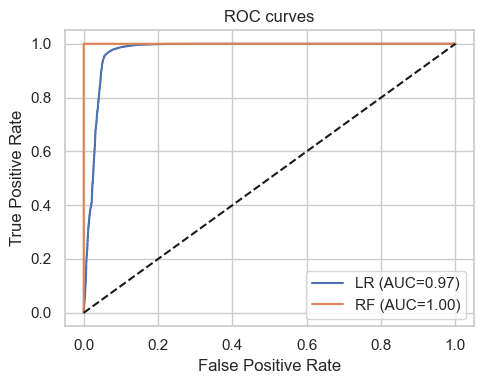

In [28]:
# Comparison table
results = [
    ('Logistic Regression', recall_score(y_test_cls, y_pred_cls_lr, pos_label=1), f1_score(y_test_cls, y_pred_cls_lr, pos_label=1), roc_auc_score(y_test_cls, lr.predict_proba(X_test)[:, 1]), np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_ridge)), r2_score(y_test_reg, y_pred_reg_ridge)),
    ('Random Forest',       recall_score(y_test_cls, y_pred_cls_rf, pos_label=1), f1_score(y_test_cls, y_pred_cls_rf, pos_label=1), roc_auc_score(y_test_cls, rf_cls.predict_proba(X_test)[:, 1]), np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_rf)), r2_score(y_test_reg, y_pred_reg_rf)),
]
table = pd.DataFrame(results, columns=['Model', 'Recall(late)', 'F1(late)', 'ROC-AUC', 'RMSE', 'R²'])
print('Test set — classification and regression')
display(table.round(3))

# Optional: ROC curve for both classifiers
fig, ax = plt.subplots(figsize=(5, 4))
for name, y_pred, y_proba in [('LR', y_pred_cls_lr, lr.predict_proba(X_test)[:, 1]), ('RF', y_pred_cls_rf, rf_cls.predict_proba(X_test)[:, 1])]:
    fpr, tpr, _ = roc_curve(y_test_cls, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test_cls, y_proba):.2f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate'); ax.set_title('ROC curves'); ax.legend()
plt.tight_layout(); plt.show()

---

## 9. Feature importance

Random Forest gives **feature importances** for both the classifier and the regressor. Plot the top drivers so a logistics manager can see which levers (e.g. shipping mode, region, category) matter most for late risk and delay magnitude.

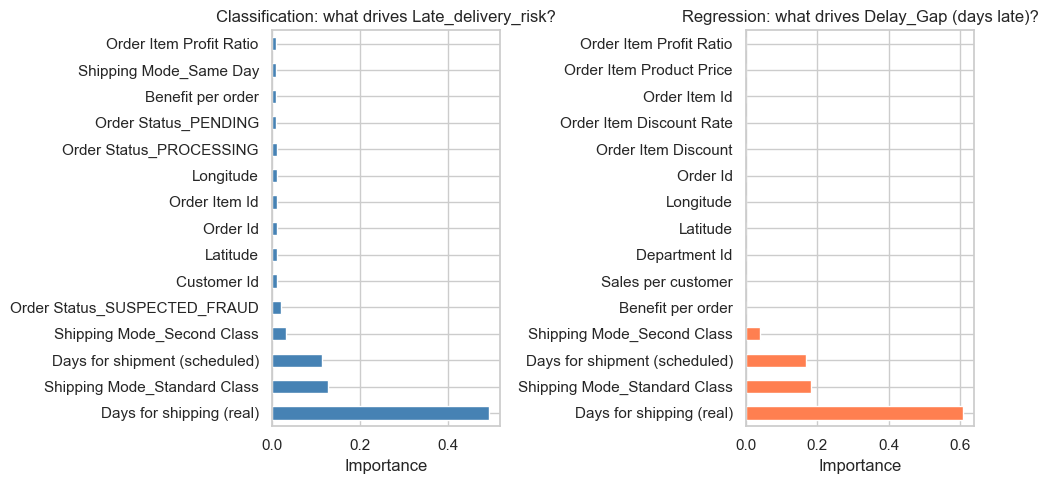

Takeaway: prioritize interventions on orders with high-risk shipping modes, regions, and categories that appear at the top of these lists.


In [29]:
# Top features: classification (late vs not) and regression (delay magnitude)
imp_cls = pd.Series(rf_cls.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_reg = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
imp_cls.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Classification: what drives Late_delivery_risk?')
axes[0].set_xlabel('Importance')
imp_reg.head(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Regression: what drives Delay_Gap (days late)?')
axes[1].set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Takeaway: prioritize interventions on orders with high-risk shipping modes, regions, and categories that appear at the top of these lists.')

---

## Summary

We delivered **two models in one pipeline**: a classifier for *will it be late?* and a regressor for *by how many days?*, then combined them into an **actionable Risk Score** for prioritization. Next steps: (1) tune RF (e.g. `GridSearchCV`) if more performance is needed, (2) export risk scores to a dashboard or daily report, (3) validate on a holdout period if temporal data is available.